In [78]:
import pandas as pd
import re

In [79]:

# Load dataset
df = pd.read_csv("complaints.csv")  # if you're in Colab, update path accordingly

In [80]:
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [81]:
df.isnull().sum()

,0
Unnamed: 0,0
product,0
narrative,10


In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,162421.0,81210.0,46887.048373,0.0,40605.0,81210.0,121815.0,162420.0


In [84]:
#  Keep only useful columns (drop index-like column if present)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [85]:
# Rename to consistent names (optional but helps)
# Your dataset uses: narrative (text) and product (label)
df = df.rename(columns={"narrative": "text", "product": "label"})

In [86]:
# Basic trimming (remove extra spaces)
df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()

In [87]:
# Drop duplicate complaints (optional but usually helpful)
df = df.drop_duplicates(subset=["text", "label"]).copy()

In [88]:
# Text cleaning function (safe + standard for NLP)
def clean_text(s: str) -> str:
    s = s.lower()

    # remove URLs
    s = re.sub(r"http\S+|www\.\S+", " ", s)

    # remove emails
    s = re.sub(r"\S+@\S+", " ", s)

    # remove digits (keep if you think numbers matter, e.g., amounts, dates)
    s = re.sub(r"\d+", " ", s)

    # keep letters + spaces only (removes punctuation/symbols)
    s = re.sub(r"[^a-z\s]", " ", s)

    # remove extra spaces
    s = re.sub(r"\s+", " ", s).strip()

    return s


In [89]:
# Create cleaned text column (do NOT overwrite raw text)
df["clean_text"] = df["text"].apply(clean_text)

In [90]:
# Remove rows where cleaned text becomes empty
df = df[df["clean_text"].str.len() > 0].copy()


In [91]:
#  Quick checks
print("Shape after cleaning:", df.shape)

Shape after cleaning: (124679, 3)


In [92]:
print("\nMissing values:\n", df[["text", "label", "clean_text"]].isna().sum())


Missing values:
 text          0
label         0
clean_text    0
dtype: int64


In [93]:
print("\nTop 10 labels:\n", df["label"].value_counts().head(10))



Top 10 labels:
 label
credit_reporting       56304
debt_collection        21118
mortgages_and_loans    18759
credit_card            15024
retail_banking         13474
Name: count, dtype: int64


In [94]:
print("\nSample cleaned text:\n", df["clean_text"].head(3).tolist())


Sample cleaned text:
 ['purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company responded im sorry inform due unusually high order volume order shipped several week stock since early due high demand although continuing take order guaranteeing receive order place due time mask order exact shipping date right however guarantee ship soon soon delivers product u getting small shipment shipping first come first served basis appreciate patience fulfill order quickly recommend keeping order lose place line cancel distributor stock moment prefer cancel please note ask via email cancel accordance cancellation policy agreed checkout electronic inventory online requested order canceled refund issued canceled order sent verification order canceled refunded item particulate respirator refunded subtotal shipping tax total usd visa ending refund called disputed amount stated nothing needed submitted address issue recharg

In [95]:
# Save cleaned dataset for next steps (TF-IDF, modelling, etc.)
df.to_csv("complaints_cleaned.csv", index=False)
print("\nSaved: complaints_cleaned.csv")


Saved: complaints_cleaned.csv


In [96]:
df = pd.read_csv("complaints_cleaned.csv")
print("Shape:", df.shape)


Shape: (124679, 3)


In [97]:
print(df.head(3))

            label                                               text  \
0     credit_card  purchase order day shipping amount receive pro...   
1     credit_card  forwarded message date tue subject please inve...   
2  retail_banking  forwarded message cc sent friday pdt subject f...   

                                          clean_text  
0  purchase order day shipping amount receive pro...  
1  forwarded message date tue subject please inve...  
2  forwarded message cc sent friday pdt subject f...  


In [98]:
print("\nColumns:", df.columns.tolist())


Columns: ['label', 'text', 'clean_text']


In [99]:
print("Missing values:\n", df.isna().sum())

dupes = df.duplicated(subset=["clean_text", "label"]).sum()
print("\nDuplicate rows (clean_text + label):", dupes)


Missing values:
 label         0
text          3
clean_text    3
dtype: int64

Duplicate rows (clean_text + label): 0


In [100]:
label_counts = df["label"].value_counts()
print(label_counts.head(15))
print("\nNumber of unique labels:", df["label"].nunique())

label
credit_reporting       56304
debt_collection        21118
mortgages_and_loans    18759
credit_card            15024
retail_banking         13474
Name: count, dtype: int64

Number of unique labels: 5


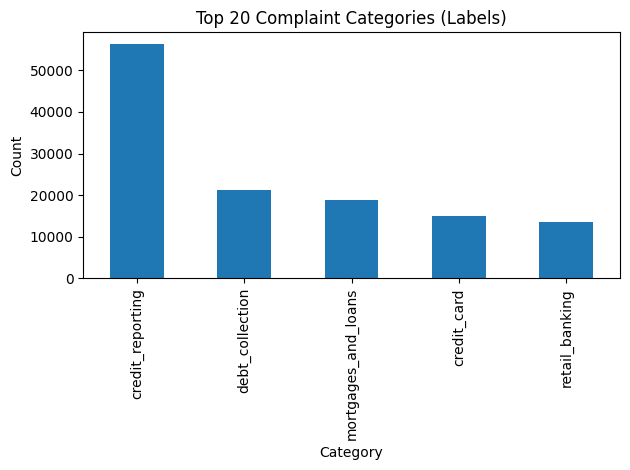

In [101]:
import matplotlib.pyplot as plt

top_n = 20
label_counts.head(top_n).plot(kind="bar")
plt.title(f"Top {top_n} Complaint Categories (Labels)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [102]:
df["raw_len"] = df["text"].astype(str).str.split().apply(len)
df["clean_len"] = df["clean_text"].astype(str).str.split().apply(len)

print(df[["raw_len", "clean_len"]].describe(percentiles=[.5, .75, .9, .95, .99]))


             raw_len      clean_len
count  124679.000000  124679.000000
mean       87.114983      87.114983
std       110.874840     110.874840
min         1.000000       1.000000
50%        58.000000      58.000000
75%       104.000000     104.000000
90%       180.000000     180.000000
95%       252.000000     252.000000
99%       501.000000     501.000000
max      2685.000000    2685.000000


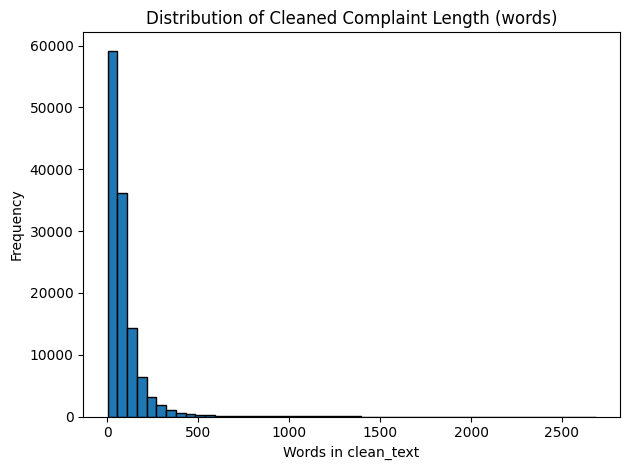

In [103]:
import matplotlib.pyplot as plt

df["clean_len"].plot(kind="hist", bins=50,edgecolor = 'black')
plt.title("Distribution of Cleaned Complaint Length (words)")
plt.xlabel("Words in clean_text")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [104]:
print("Very short (<= 5 words):", (df["clean_len"] <= 5).sum())
print("Very long (>= 300 words):", (df["clean_len"] >= 300).sum())

df.sort_values("clean_len").head(3)[["label", "clean_len", "clean_text"]]

Very short (<= 5 words): 1690
Very long (>= 300 words): 4262


,label,clean_len,clean_text
124678,credit_reporting,1,name
124677,credit_card,1,name
124676,debt_collection,1,name


In [105]:
from collections import Counter

words = " ".join(df["clean_text"].astype(str)).split()
counter = Counter(words)

print("Total tokens:", len(words))
print("Unique tokens:", len(counter))
print("\nTop 25 words:", counter.most_common(25))


Total tokens: 10861409
Unique tokens: 45992

Top 25 words: [('account', 252929), ('credit', 239624), ('report', 124293), ('payment', 118364), ('information', 104300), ('time', 73355), ('would', 72341), ('loan', 70670), ('company', 67883), ('card', 66770), ('bank', 65817), ('debt', 62534), ('reporting', 62510), ('day', 61029), ('received', 60299), ('letter', 56363), ('told', 53516), ('sent', 49850), ('never', 49402), ('call', 49077), ('called', 47571), ('dispute', 46428), ('number', 45013), ('also', 43641), ('due', 43082)]


In [106]:
from collections import Counter

top_labels = df["label"].value_counts().head(3).index.tolist()

for lab in top_labels:
    words_lab = " ".join(df.loc[df["label"] == lab, "clean_text"].astype(str)).split()
    print("Label:", lab, "-Samples:", (df["label"] == lab).sum())
    print("Top 20 words:", Counter(words_lab).most_common(20))


Label: credit_reporting -Samples: 56304
Top 20 words: [('credit', 150693), ('account', 129067), ('report', 94262), ('information', 70342), ('reporting', 49830), ('payment', 37369), ('dispute', 28836), ('inquiry', 27080), ('consumer', 26662), ('letter', 25834), ('company', 25329), ('date', 25169), ('bureau', 25073), ('day', 23891), ('time', 23328), ('agency', 21020), ('experian', 20620), ('late', 20490), ('balance', 20093), ('reported', 20052)]
Label: debt_collection -Samples: 21118
Top 20 words: [('debt', 39966), ('credit', 35816), ('account', 31503), ('collection', 20606), ('report', 18484), ('company', 17746), ('information', 14343), ('letter', 12040), ('received', 11708), ('payment', 11572), ('call', 11173), ('time', 10561), ('never', 9700), ('sent', 9497), ('would', 9461), ('reporting', 8679), ('agency', 8648), ('amount', 8537), ('called', 8043), ('number', 7887)]
Label: mortgages_and_loans -Samples: 18759
Top 20 words: [('payment', 47273), ('loan', 44123), ('mortgage', 26562), ('w

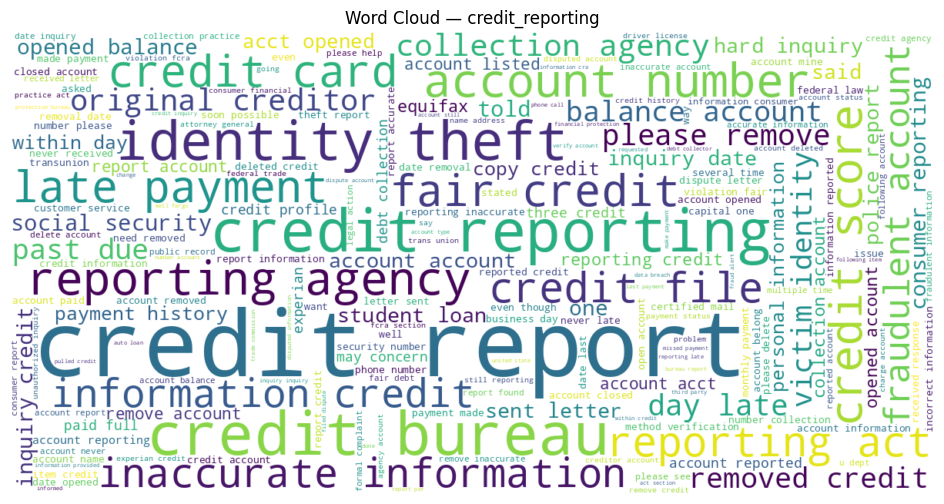

In [107]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

one_label = df["label"].value_counts().index[0]
text_blob = " ".join(df.loc[df["label"] == one_label, "clean_text"].astype(str))

wc = WordCloud(width=1200, height=600, background_color="white").generate(text_blob)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud — {one_label}")
plt.show()


In [108]:
# Train & Test
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (99743,)
Test size : (24936,)


In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=5,
    max_features=50000
)

# Fill NaN values with empty strings before TF-IDF vectorization
X_train_tfidf = tfidf.fit_transform(X_train.fillna(''))
X_test_tfidf = tfidf.transform(X_test.fillna(''))

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)

TF-IDF train shape: (99743, 50000)
TF-IDF test shape : (24936, 50000)


# NAIVE BAYES

In [110]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8286413217837665
                     precision    recall  f1-score   support

        credit_card       0.75      0.77      0.76      3005
   credit_reporting       0.87      0.86      0.87     11261
    debt_collection       0.82      0.71      0.76      4223
mortgages_and_loans       0.76      0.88      0.82      3752
     retail_banking       0.85      0.88      0.86      2695

           accuracy                           0.83     24936
          macro avg       0.81      0.82      0.81     24936
       weighted avg       0.83      0.83      0.83     24936



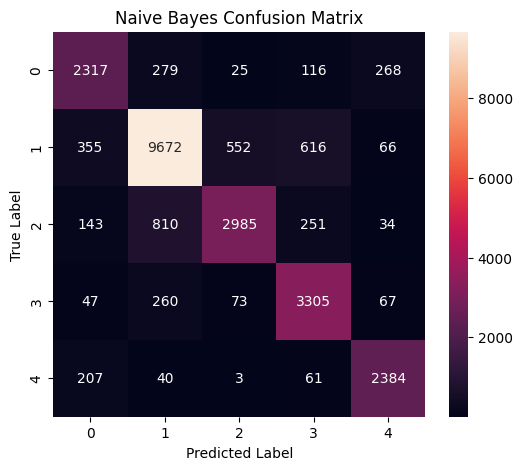

In [111]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# RANDOM fOREST

In [112]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6441690728264357
                     precision    recall  f1-score   support

        credit_card       0.89      0.28      0.43      3005
   credit_reporting       0.57      0.99      0.73     11261
    debt_collection       0.93      0.20      0.34      4223
mortgages_and_loans       0.91      0.52      0.66      3752
     retail_banking       0.88      0.46      0.61      2695

           accuracy                           0.64     24936
          macro avg       0.84      0.49      0.55     24936
       weighted avg       0.76      0.64      0.60     24936



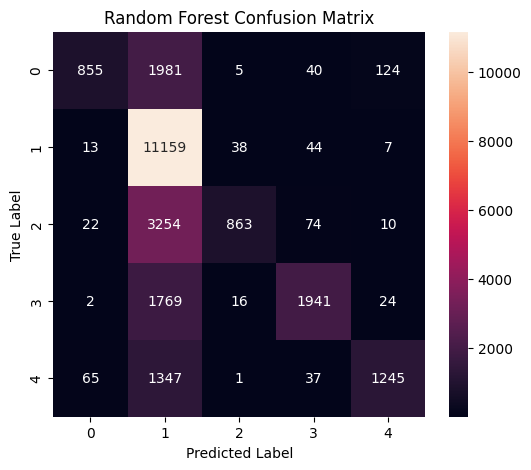

In [113]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## SVM

In [114]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Linear SVM Accuracy: 0.8570340070580686
                     precision    recall  f1-score   support

        credit_card       0.81      0.78      0.80      3005
   credit_reporting       0.89      0.91      0.90     11261
    debt_collection       0.80      0.78      0.79      4223
mortgages_and_loans       0.87      0.83      0.85      3752
     retail_banking       0.86      0.89      0.87      2695

           accuracy                           0.86     24936
          macro avg       0.84      0.84      0.84     24936
       weighted avg       0.86      0.86      0.86     24936



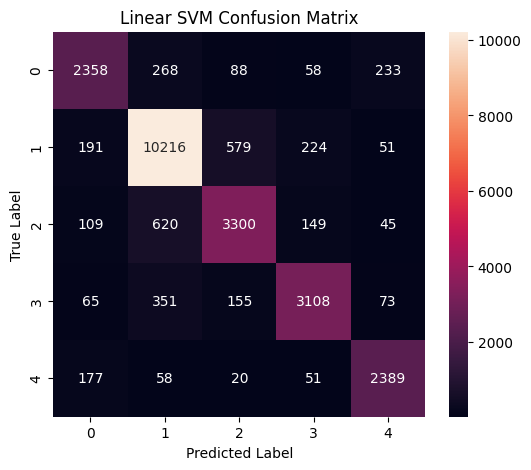

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## COMPARISION OF ALL MODELS

In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# List to store results for each model
all_results = []

# Naive Bayes
all_results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_nb),
    "Precision": precision_score(y_test, y_pred_nb, average="weighted"),
    "Recall": recall_score(y_test, y_pred_nb, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_nb, average="weighted")
})

# Random Forest
all_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, average="weighted"),
    "Recall": recall_score(y_test, rf_pred, average="weighted"),
    "F1 Score": f1_score(y_test, rf_pred, average="weighted")
})

# Linear SVM
all_results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, average="weighted"),
    "Recall": recall_score(y_test, y_pred_svm, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_svm, average="weighted")
})

results_df = pd.DataFrame(all_results)

print(results_df.sort_values(by="Accuracy", ascending=False))

           Model  Accuracy  Precision    Recall  F1 Score
2     Linear SVM  0.857034   0.856407  0.857034  0.856537
0    Naive Bayes  0.828641   0.830567  0.828641  0.828128
1  Random Forest  0.644169   0.756464  0.644169  0.601113


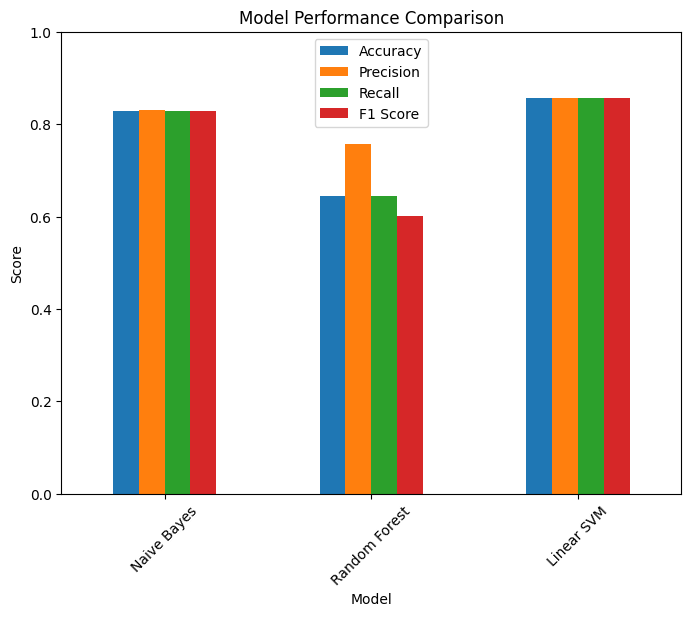

In [128]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(8,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.show()

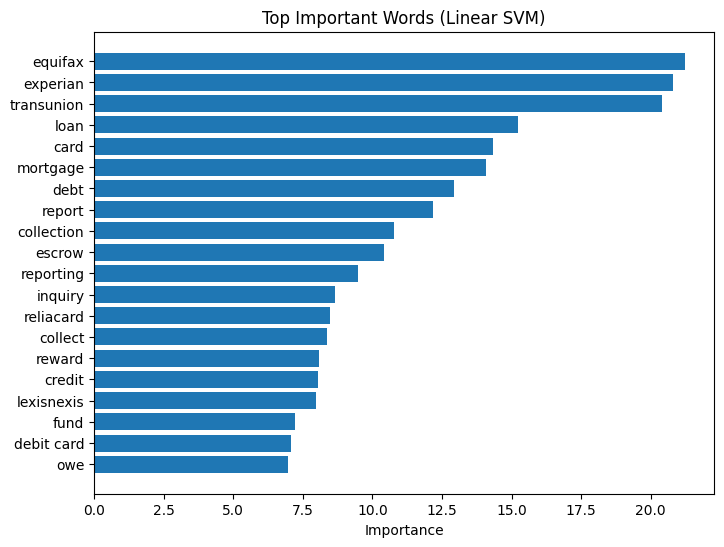

In [132]:

feature_names = tfidf.get_feature_names_out()

# Calculate importance from coefficients for LinearSVC
importances = np.sum(np.abs(svm.coef_), axis=0)

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.title("Top Important Words (Linear SVM)")
plt.xlabel("Importance")

plt.show()

# TOP CATAGORIES

<Figure size 1200x1000 with 0 Axes>

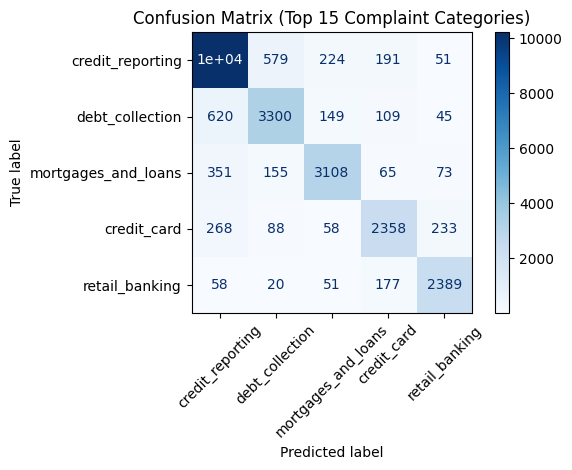

In [117]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_svm)
# get top 15 most frequent labels
top_labels = y_test.value_counts().head(15).index.tolist()

mask = y_test.isin(top_labels)
y_test_top = y_test[mask]
y_pred_top = pd.Series(y_pred_svm, index=y_test.index)[mask]

cm_top = confusion_matrix(y_test_top, y_pred_top, labels=top_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_top,
    display_labels=top_labels
)

plt.figure(figsize=(12, 10))
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix (Top 15 Complaint Categories)")
plt.tight_layout()
plt.show()


In [118]:
errors = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": y_pred_svm,
    "text": X_test
})

errors["is_error"] = errors["true_label"] != errors["predicted_label"]

print("Total test samples:", len(errors))
print("Total misclassified samples:", errors["is_error"].sum())


Total test samples: 24936
Total misclassified samples: 3565


In [122]:
# TRUR LABEL VS PREDICTED LABEL
confusion_pairs = (
    errors[errors["is_error"]]
    .groupby(["true_label", "predicted_label"])
    .size()
    .sort_values(ascending=False)
)

confusion_pairs.head(10)


true_label           predicted_label    
debt_collection      credit_reporting       620
credit_reporting     debt_collection        579
mortgages_and_loans  credit_reporting       351
credit_card          credit_reporting       268
                     retail_banking         233
credit_reporting     mortgages_and_loans    224
                     credit_card            191
retail_banking       credit_card            177
mortgages_and_loans  debt_collection        155
debt_collection      mortgages_and_loans    149
dtype: int64

In [120]:
errors[errors["is_error"]].sample(5)[
    ["true_label", "predicted_label", "text"]
]


,true_label,predicted_label,text
51345,retail_banking,credit_card,purchased item seller never sent item seller b...
105635,credit_reporting,credit_card,effect fraud account new purchase game point g...
27423,credit_reporting,mortgages_and_loans,bought car company promised month warranty tol...
10931,credit_card,credit_reporting,creditor citi add sd acct creditor never commu...
46190,debt_collection,credit_reporting,written letter national credit system debt val...


In [121]:
class_accuracy = (
    errors.assign(correct=~errors["is_error"])
    .groupby("true_label")["correct"]
    .mean()
    .sort_values()
)

class_accuracy.head(10)


,correct
true_label,
debt_collection,0.781435
credit_card,0.784692
mortgages_and_loans,0.828358
retail_banking,0.886456
credit_reporting,0.907202
